In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from dataclasses import dataclass
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.nn import functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import random
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm, trange
import csv
import os
import optuna

/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/mwhealing/miniforge3/envs/AIenv/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/mwhealing/m

In [3]:
seed = 88
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:


class MetricLogger:
    def __init__(self, filepath):
        self.filepath = filepath
        self.headers = ["epoch", "train_loss", "val_loss", "alpha", "beta", "lambda_val", "num_samples"]
        if not os.path.exists(filepath):
            with open(filepath, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(self.headers)

    def log(self, epoch, train_loss, val_loss, alpha,  beta, lambda_val, num_samples):
        with open(self.filepath, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([epoch, train_loss, val_loss, alpha,  beta,lambda_val, num_samples])


In [5]:
# ==== Configuration ==== #
@dataclass
class ModelConfig:
    def __init__(self):
        self.block_size = 32 # context size (min num of tokens in sequence, how long model can see at once)
        self.vocab_size = 50256
        self.max_iters = 100
        self.n_head = 4
        self.n_embd = 64
        self.n_layers = 6
        self.dropout = 0.1
        self.bias: bool = True
        self.device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
                                          # switch out when transferring to github or stanage for cuda use

@dataclass
class TrainConfig:
    epochs: int = 20
    batch_size: int = 32
    max_len: int = 64
    pad: int = 0
    grad_accum_steps: int = 1
    max_lr: float = 3e-4
    min_lr: float = 1e-5
    warmup_iters: int = 100
    n_steps: int = 0
    lr_decay_iters: int = 1000
    save_checkpoints: bool = False
    save_every: int = 1
    save_every_steps:int = 2000
    #alpha: float = 0.7 # [0,1] . 0 => entropy only ; 1 => loss only
    # add optimiser hp





# Proxy Model 

In [6]:
@dataclass
class ProxyConfig:
    epochs:int = 5
    vocab_size:int = ModelConfig().vocab_size    # keep same vocab
    block_size:int = ModelConfig().block_size    # same context length
    batch_size:int = 32
    n_embd:int = 128                        # e.g. 1/4 or 1/8 of main
    n_head :int = 4                          # just enough heads
    n_layers:int = 2                          # really small depth
    dropout:float = 0.1
    bias: bool = False
    min_lr: float = 1e-4
    max_lr: float = 3e-4
    device  = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    # Proxy steps
    T_steps:int = 1_00
    t0:int = 5_0
    step:int = 0

    alpha_scale:float = 0.7 # keep [0,1] range


In [7]:
class ProxyTrain(torch.nn.Module):
    def __init__(self, holdout_loader: DataLoader, score_loader: DataLoader, configs, model_cls):
        super().__init__()
        # Loader for training proxy
        self.holdout_loader = holdout_loader
        # Loader for computing learnability on unseen data
        self.score_loader = score_loader
        self.configs = configs
        self.device = configs.device

        # Build and move proxy model
        self.train_model = model_cls(configs).to(self.device)
        self.optim = torch.optim.AdamW(self.train_model.parameters(), lr=configs.max_lr)

        # Loss for training uses default (mean)
        self.Loss = torch.nn.CrossEntropyLoss()
        # Model class for fresh instances
        self.model_cls = model_cls

    def train(self):
        hold_iter = iter(self.holdout_loader)
        for step in trange(1, self.configs.T_steps + 1, desc="Proxy training"):
            try:
                x, y = next(hold_iter)
            except StopIteration:
                hold_iter = iter(self.holdout_loader)
                x, y = next(hold_iter)

            self.train_model.train()
            x, y = x.to(self.device), y.to(self.device)
            logits = self.train_model(x)  # [B, L, V]
            B, L, V = logits.shape

            loss = self.Loss(logits.view(B * L, V), y.view(-1))
            self.optim.zero_grad()
            loss.backward()
            self.optim.step()

            if step % 1000 == 0:
                print(f"Proxy step {step}/{self.configs.T_steps}, loss={loss.item():.4f}")

            if step == self.configs.t0:
                torch.save(self.train_model.state_dict(), f"proxy_early_{self.configs.block_size}.pt")
                print(f"Saved proxy early checkpoint at step {step}")

        # final checkpoint
        torch.save(self.train_model.state_dict(), f"proxy_late_{self.configs.block_size}.pt")
        print(f"Saved proxy final checkpoint at step {self.configs.T_steps}")
        


    def reductionLoss(self, model, inputs, targets):
        logits = model(inputs)         # [B, L, V]
        B, L, V = logits.shape
        loss_fn = torch.nn.CrossEntropyLoss(reduction="none")
        token_loss = loss_fn(logits.view(B * L, V), targets.view(-1))  # [B*L]
        seq_loss = token_loss.view(B, L).mean(dim=1)                   # [B]
        return seq_loss
    
    def sequenceEntropy(self, model, inputs):
        logits = model(inputs)
        B, L, V = logits.shape
        token_probs = F.softmax(logits, dim=-1) # [B, L, V]
        log_probs = torch.log(token_probs + 1e-8)
        token_entropy = -torch.sum(token_probs * log_probs, dim=-1) # [B, L]
        seq_entropy = token_entropy.mean(dim=1) # [B]
        return seq_entropy


    def LearnabilityScore(self, type='composite'):

        # Load early proxy
        early = self.model_cls(self.configs).to(self.device)
        early.load_state_dict(torch.load(f"proxy_early_{self.configs.block_size}.pt", weights_only=True))
        early.eval()
        # Load late proxy
        late = self.model_cls(self.configs).to(self.device)
        late.load_state_dict(torch.load(f"proxy_late_{self.configs.block_size}.pt", weights_only=True))
        late.eval()

        all_deltas = []
        abs_entropys = []
        with torch.no_grad():
            for x, y in tqdm(self.score_loader):
                x, y = x.to(self.device), y.to(self.device)
                loss_early = self.reductionLoss(early, x, y)
                loss_late  = self.reductionLoss(late,  x, y)
                delta = loss_early - loss_late
                all_deltas.append(delta)

                entropy_late = self.sequenceEntropy(late, x)
                abs_entropys.append(entropy_late)
            
        irr_loss = torch.cat(all_deltas, dim=0)
        entropy = torch.cat(abs_entropys, dim=0)

        eps = 1e-8

        # normalise for composite score
        norm_irr = (irr_loss - torch.min(irr_loss)) / (torch.max(irr_loss) - torch.min(irr_loss) + eps)
        norm_entropy = (entropy - torch.min(entropy)) / (torch.max(entropy) - torch.min(entropy) + eps)

        # return flat tensor of learnability scores
        if type == 'Loss':
            return irr_loss
        if type == 'Entropy':
            return entropy
        elif type == 'composite':
            comp_score = self.configs.alpha_scale * norm_irr + (1 - self.configs.alpha_scale)*norm_entropy
            return comp_score

        
        

In [8]:
class Scheduler:
    def __init__(self, train_data, scores, configs, schedule_type:str, init_beta:float, shuffle:bool ):
        super().__init__()

        self.train_data = train_data
        self.scores = scores
        self.configs = configs

        self.schedule_type = schedule_type
        self.init_beta = init_beta
        self.shuffle = shuffle

        self.sorted_idcs = self.scoreSort()

        self.gamma = 0.1

    def scoreSort(self):
        score = self.scores.cpu().numpy() # make sure still a tensor when passed

        pairs = list(enumerate(score))
        sorted_pairs = sorted(pairs, key=lambda pair: pair[1])
        sorted_idcs = [idc for idc, _ in sorted_pairs]

        return sorted_idcs
    
    def lyapunovReguliser(self, epoch, lambda_n):
        if len(lambda_n)<2:
            return 1.
        
        delta_lambda = lambda_n[-1] - lambda_n[-2]
        alpha = 1.

        if delta_lambda >= 0: # unstable condition => reduce speed
            alpha *= (1 - self.gamma*lambda_n[-1]/(1 + epoch))

        else: # stable condition => increase speed
            alpha *= (1 + self.gamma*lambda_n[-1]/(1 + epoch))

        return alpha

    def betaSchedule(self,epoch, alpha): # alpha is inital sampling size. 
        # adaptive scaling. adapt during training based on validation performance?
        # if feedback (val) stronger than scaling type, will schedule type wash out?
        print(f"[{self.schedule_type}]")
        E_n = epoch / self.configs.epochs # current epoch ratio
        eps = 1e-8
        if self.schedule_type == 'linear': # schedules the sampling linearly (default)
            beta_t = min(1., self.init_beta + E_n)
        if self.schedule_type == 'sigmoid':
            beta_t = (1 + math.exp(-alpha * E_n))**-1 
        if self.schedule_type == 'tanh':
            beta_t = 0.5*math.tanh(alpha * E_n) + 0.5
        if self.schedule_type == 'log':
            beta_t = min(1., math.log(alpha * E_n + eps))
        if self.schedule_type == 'exp':
            beta_t = min(1., math.exp(alpha * E_n) - 1 + eps)
        
        self.current_beta = beta_t
        self.prct_seen = beta_t * 100
        # sampling %
        cutoff = max(1., int(beta_t * len(self.sorted_idcs))) 
        sample_idcs = self.sorted_idcs[:cutoff] # sample from sorted indicies 

        if self.shuffle:
            random.shuffle(sample_idcs) # shuffle idcs in sample
        return sample_idcs

    def seqentialBatch(self, epoch, alpha):
        sampled_idcs = self.betaSchedule(epoch, alpha)
        subset = torch.utils.data.Subset(self.train_data, sampled_idcs)
        
        train_loader = DataLoader(
            subset, 
            batch_size=self.configs.batch_size,
            )
        return train_loader

# GPT2 Decoder #

Components:

1. Token Embeddings - Map token ids to dense vecs

2. Positional Encoding - add positional info to embeddings

3. Transformer Blocks (n) - self-attention + feed foward layers

4. Casual masking - prevents peeking into future

5. Final Linear Layer - projects to vocab size (logits)

In [9]:
# ==== GPT2 Decoder ==== #

### UPDATE FOR TORCH USE ###

class GPT2Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.config = config

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias) # create W attn embds
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        # layer norm
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)

        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias), # expand dims (4 * from Attention all u need paper)
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd), # project back 
            nn.Dropout(config.dropout)
        )
        
        self.attn_dropout = nn.Dropout(config.dropout)

    def Mask(self, t):
        mask = torch.tril(torch.ones((t,t), device=self.config.device)).unsqueeze(0).unsqueeze(0)
        return mask

    def SelfAttention(self,x, mask=None):
        b,t,c = x.shape
        q, k, v = self.c_attn(x).split(self.config.n_embd, dim=2)
        
        q =q.reshape(b, t, self.config.n_head, c//self.config.n_head).permute(0,2,1,3)
        k = k.reshape(b, t, self.config.n_head, c//self.config.n_head).permute(0,2,1,3)
        v = v.reshape(b, t, self.config.n_head, c//self.config.n_head).permute(0,2,1,3)

        score = (q @ k.transpose(-2,-1)) / math.sqrt(k.shape[-1])

        if mask is None:
            mask = self.Mask(t)
        score = score.masked_fill(mask==0, float("-inf"))

        a = nn.functional.softmax(score, dim=-1)
        a = self.attn_dropout(a)
        head = a @ v
        out = head.permute(0,2,1,3).reshape(b,t,c) # back to input dims
        out = self.c_proj(out)
        #print("Type of self.SelfAttention(x):", type(out))
        return out
    
    def forward(self, x, mask=None):
        # self attention ad layer norm
        x = x + self.SelfAttention(self.ln1(x), mask)
        x = x + self.mlp(self.ln2(x)) # resudual connections
       
        return x
    
class GPT2Model(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.token_embd = nn.Embedding(config.vocab_size, config.n_embd)
        self.posn_embd = nn.Embedding(config.block_size, config.n_embd)

        self.proj = nn.Linear(config.n_embd, config.vocab_size)

        self.blocks = nn.Sequential(*[GPT2Block(config) for _ in range(config.n_layers)])
        self.fln = nn.LayerNorm(config.n_embd)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.ones_(module.weight)
            torch.nn.init.zeros_(module.bias)

    def forward(self, x):
        b, t = x.size()
        tokn_embd = self.token_embd(x)
        posn_idcs = torch.arange(t, device=x.device).unsqueeze(0).expand(b,t)
        posn_embd = self.posn_embd(posn_idcs)

        x = tokn_embd + posn_embd

        x = self.blocks(x)
        x = self.fln(x) # final linear layer
        return self.proj(x) # project back to (enbedding size, vocab size)



class GPTTrainer:
    def lr_schedule(self, optim, train_config):
        def lr_lambda(current_step):
            if current_step < train_config.warmup_iters:
                return float(current_step) / float(max(1, train_config.warmup_iters))
            return max(0.0, float(train_config.total_steps - current_step) / float(max(1, train_config.total_steps - train_config.warmup_iters)))
        return LambdaLR(optim, lr_lambda)

    def __init__(self, x, y, train_loader, val_loader, train_config, model_config, scheduler, check_points_dir=None):
        self.x, self.y = x, y
        self.train_config = train_config
        self.save_checkpoints = train_config.save_checkpoints
        self.check_points_dir = check_points_dir

        self.train_loader = train_loader
        self.val_loader = val_loader
        self.scheduler = scheduler

        self.device = model_config.device

        self.train_config.total_steps = self.train_config.epochs * len(self.train_loader)

        self.model = GPT2Model(model_config).to(self.device)
        self.optim = torch.optim.AdamW(self.model.parameters(), lr=train_config.max_lr)
        self.schedule = self.lr_schedule(self.optim, self.train_config)
        self.criterion = nn.CrossEntropyLoss()

        self.step_count = 0

        # lyponav regularisation
        self.L0 = None # get initial val loss
        self.prev_val_loss = None # get prev val loss
        self.lambdas = [] # track lambda of leraning over time


    def step(self, inputs, targets):
        self.model.train()
        inputs = inputs.to(self.device)
        targets = targets.to(self.device)

        logits = self.model(inputs)
        b, t, v = logits.shape
        logits = logits.view(b * t, v)
        targets = targets.view(b * t)

        loss = self.criterion(logits, targets) / self.train_config.grad_accum_steps
        loss.backward()

        if (self.step_count + 1) % self.train_config.grad_accum_steps == 0:
            self.optim.step()
            self.schedule.step()
            self.optim.zero_grad()

        self.step_count += 1

        if self.train_config.save_checkpoints and (self.check_points_dir and self.step_count % self.train_config.save_every_steps == 0):
            checkpoint = {
                "step": self.step_count,
                "model": self.model.state_dict(),
                "optim": self.optim.state_dict(),
                "schedule": self.schedule.state_dict()
            }
            torch.save(checkpoint, f"{self.check_points_dir}/checkpoint_step_{self.step_count}.pt")
            print(f" ------> Saved Checkpoint at {self.step_count}")

        if self.step_count % 1000 ==0:
            print(f"Step {self.step_count:04d} | Loss: {loss.item():.4f}")
        return loss.item()

    def validate(self, val_loader):
        self.model.eval()

        total_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(self.device)
                y = y.to(self.device)

                logits = self.model(x)
                b, t, v = logits.shape
                logits = logits.view(b * t, v)
                y = y.view(b * t)

                loss = self.criterion(logits, y)
                total_loss += loss.item()
        return total_loss / len(val_loader)

    def train(self):
        logger = MetricLogger("logs/train_metrics.csv")

        alpha = 1.
        train_loss_arr = []
        val_loss_arr = []
        alpha_arr = []
        lambdas_arr = []

        for epoch in range(self.train_config.epochs):
            total_loss = 0.
            n_batches = 0
            if self.lambdas:
                alpha *= self.scheduler.lyapunovReguliser(epoch, self.lambdas)
                alpha_arr.append(alpha)
                lambdas_arr.append(self.lambdas[-1])

            train_loader = self.scheduler.seqentialBatch(epoch, alpha)

            if self.step_count > 0:
                current_lr = self.optim.param_groups[0]['lr']
                print(f"Epoch {epoch + 1} | LR: {current_lr:.6f}")
            else:
                print(f"Epoch {epoch + 1} | Starting warmup...")

            for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}, alpha {alpha}"):
                loss_val = self.step(x, y)
                total_loss += loss_val
                n_batches += 1

            avg_loss = total_loss / n_batches
            train_loss_arr.append(avg_loss)
    
            val_loss = self.validate(self.val_loader)
            val_loss_arr.append(val_loss)

            # regularise sample scaling 
            if self.L0 is None:
                self.L0 = val_loss # get initial validation loss
            if self.prev_val_loss is not None:
                delta_L = val_loss - self.prev_val_loss
                if delta_L != 0:
                    lambda_n = (1/(1+epoch)) * math.log(abs(delta_L)/self.L0)  # measure divergence
                    self.lambdas.append(lambda_n)
                    print(lambda_n)

            self.prev_val_loss = val_loss # update prev

            print(f"Epoch {epoch + 1} | Training Loss: {avg_loss:.2f} | Validation Loss: {val_loss:.4f}")
            
            # logging for analysis
            lambda_val = self.lambdas[-1] if self.lambdas else 0.0
            beta_t = self.scheduler.current_beta
            prct_samples = self.scheduler.prct_seen
            # add epoch avg scores + mean and std, min and max

            logger.log(
                epoch=epoch + 1,
                train_loss=avg_loss,
                val_loss=val_loss,
                alpha=alpha,
                beta=beta_t,
                lambda_val=lambda_val,
                num_samples=prct_samples
                )

            if self.check_points_dir and (epoch + 1) % self.train_config.save_every == 0:
                torch.save(self.model.state_dict(), f"{self.check_points_dir}/model_epoch_{epoch + 1}.pt")
        return train_loss_arr, val_loss_arr, alpha_arr, lambdas_arr



# Helper function for filtering logits using top-k and/or nucleus (top-p) sampling
def top_k_top_p_filtering(logits, top_k=0, top_p=0.0, filter_value=-float('Inf')):

    # Top-K filtering: keep only k highest tokens
    if top_k > 0:
        values, indices = torch.topk(logits, top_k)
        threshold = values[-1]
        logits[logits < threshold] = filter_value

    # Top-p (nucleus) filtering
    if top_p > 0.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
        # Remove tokens with cumulative probability above the threshold
        sorted_indices_to_remove = cumulative_probs > top_p
        # Shift the indices to retain the first token above the threshold
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0

        indices_to_remove = sorted_indices[sorted_indices_to_remove]
        logits[indices_to_remove] = filter_value
    return logits


class GenerateGPT:
    def __init__(self, model, tokenizer, prompt, max_len=50):

        self.model = model
        self.tokenizer = tokenizer
        self.prompt = prompt
        self.max_len = max_len

    def generate(self, temperature=1.0, top_k=0, top_p=0.0):
        # Set model to evaluation mode
        self.model.eval()

        # Encode the prompt into token IDs (assumes tokenizer provides a numerical encoding)
        # Make sure the prompt is encoded as a list of token IDs.
        input_ids = self.tokenizer.encode(self.prompt)
        input_tensor = torch.tensor([input_ids], device=next(self.model.parameters()).device)

        # Autoregressive generation loop
        with torch.no_grad():
            for _ in range(self.max_len):
                logits = self.model(input_tensor)
                next_token_logits = logits[0, -1, :]

                # Scale logits by temperature
                next_token_logits = next_token_logits / temperature

                # Apply top-k/top-p filtering if required
                filtered_logits = top_k_top_p_filtering(next_token_logits.clone(), top_k=top_k, top_p=top_p)
                probabilities = F.softmax(filtered_logits, dim=-1)

                # Sample the next token
                next_token = torch.multinomial(probabilities, num_samples=1).item()

                # Append sampled token to input_ids tensor
                input_tensor = torch.cat([input_tensor, torch.tensor([[next_token]], device=input_tensor.device)], dim=1)

                if next_token == self.tokenizer.eos_token_id: #end of sequence token
                    break

        # Decode the tokens back to text
        generated_text = self.tokenizer.decode(input_tensor[0].tolist())
        return generated_text

 


# Text Generation # 

Predicts next token from the given context. 

1. Input [cat sat on mat] -> token representation 

2. Feed tokens to the trained model. It will output tensor with shape [batch_size, seq_len, vocab_size], which will have the probability distribution over the vocab at each position. Only care about the last position to predict next token.

3. Pick the token. From the final distribution: Argmax for highest prob, or sample from the distribution (more creative) or use top-k/top-p (nucleus) sampling to balance diversity and equity. Then simply append token to sequence.

4. Repeat, feed the model the updated sequence back in and repeat 2 and 3 until a max length is reached or model generates and end of sequence token.

### Casual Masking ###
In training and generation, model cant peak into the future.

Tests:
- Different prompt lengths
- Adjust temperature (controls randomness in sampling)
- Add stop conditions (e.g if it generates a period or newline)
- see how model behaves w/ different types of prompt

In [10]:
with open('tokenizers/wiki_token.pkl', 'rb') as f:
    wiki_data = pickle.load(f)

def loadData(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data

wiki_data = loadData('tokenizers/wiki_token.pkl')
switchboard_data = loadData('tokenizers/switchboard_token.pkl')   
sub_titles_data = loadData('tokenizers/open_subtitles_token.pkl')    

combined_data = wiki_data + switchboard_data + sub_titles_data
random.shuffle(combined_data)
trainData_10 = loadData('tokenizers/10M_data_token.pkl') # on the 10M data
trainData_100 = loadData('tokenizers/100M_data_token.pkl') # on the 100M data
print(trainData_10[0])
print(len(trainData_10))

[320, 1654, 484, 389, 13, 29294, 826, 13, 545, 1654, 326, 2081, 13, 663, 257, 1256, 1180, 621, 1762, 287, 257, 3988, 38725, 13]
679066


In [11]:
from collections import Counter
tokens = [token for seq in trainData_10 for token in seq]
counts = Counter(tokens)
print(counts.most_common(10))

[(13, 873291), (11, 438663), (262, 392638), (284, 195145), (30, 194215), (257, 192449), (345, 190609), (290, 186148), (286, 161859), (287, 135855)]


In [12]:
flat_tokens = [token for sublist in trainData_10 for token in sublist]
flat_tokens = flat_tokens[:500_000] # just for testing

In [13]:

block_size = ModelConfig().block_size
flat_tokens_np = np.array(flat_tokens, dtype=np.int32)

n_samples = len(flat_tokens_np) - block_size

X = np.lib.stride_tricks.sliding_window_view(flat_tokens_np, block_size)[:-1]
Y = np.lib.stride_tricks.sliding_window_view(flat_tokens_np[1:], block_size)

# get final test set
X_rest, X_test, y_rest, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=88
)

# get main val set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_rest, y_rest, test_size=0.25, random_state=88
)

# *split X_train_full* into actual train set and proxy-holdout
X_train_main, X_hold, y_train_main, y_hold = train_test_split(
    X_train_full, y_train_full,
    test_size=0.10,    # 10% of the 60% = 6% of total
    random_state=42
)

X_train_tensor = torch.tensor(X_train_main, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_main, dtype=torch.long)

X_val_tensor   = torch.tensor(X_val, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)

X_hold_tensor = torch.tensor(X_hold, dtype=torch.long) # proxy model
y_hold_tensor = torch.tensor(y_hold, dtype=torch.long)




In [16]:
model_config = ModelConfig()
train_config = TrainConfig()
proxy_configs = ProxyConfig()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
hold_dataset = TensorDataset(X_hold_tensor, y_hold_tensor) # for proxy model
score_dataset = TensorDataset(X_train_tensor, y_train_tensor) # for irreducible 

train_loader = DataLoader(train_dataset, batch_size=train_config.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=train_config.batch_size)
holdout_loader = DataLoader(hold_dataset, batch_size=proxy_configs.batch_size) # proxy
score_loader = DataLoader(train_dataset, batch_size=proxy_configs.batch_size, shuffle=False) #irreducilbe 


In [ ]:


proxy_trainer = ProxyTrain(holdout_loader, score_loader, proxy_configs, GPT2Model)

proxy_trainer.train()




Proxy training:  53%|█████▎    | 53/100 [00:03<00:03, 12.76it/s]

Saved proxy early checkpoint at step 50


Proxy training: 100%|██████████| 100/100 [00:07<00:00, 13.59it/s]

Saved proxy final checkpoint at step 100


In [ ]:

scheduler = Scheduler(
    train_dataset, 
    proxy_trainer.LearnabilityScore(alpha=proxy_configs.alpha_scale, type='composite'), 
    configs=proxy_configs, 
    schedule_type='sigmoid', 
    init_beta=0.3, 
    shuffle=True
    )

sorted_idcs = scheduler.scoreSort()
print(len(sorted_idcs))

sampled_idc = scheduler.betaSchedule(epoch=1, alpha=1.1)
print(sampled_idc)

loader = scheduler.seqentialBatch(epoch=10, alpha=1.1)
for i, (x, y) in enumerate(loader):
    print("global index:", sorted_idcs[i], " example:", x[:5], "...") 
    if i == 5: break

In [ ]:


trainGPT = GPTTrainer(
    X_train_tensor, 
    y_train_tensor, 
    train_loader, 
    val_loader,    
    train_config,  
    model_config, 
    scheduler  
)


train_loss, val_loss, alphas, lambdas = trainGPT.train()



[sigmoid]
Epoch 1 | Starting warmup...


Epoch 1, alpha 1.0: 100%|██████████| 85/85 [00:05<00:00, 14.72it/s]


Epoch 1 | Training Loss: 10.33 | Validation Loss: 9.3673
[sigmoid]
Epoch 2 | LR: 0.000255


Epoch 2, alpha 1.0: 100%|██████████| 93/93 [00:06<00:00, 14.45it/s]


-0.5945191865308304
Epoch 2 | Training Loss: 7.84 | Validation Loss: 6.5148
[sigmoid]
Epoch 3 | LR: 0.000293


...

-0.2551278274255673
Epoch 18 | Training Loss: 1.53 | Validation Loss: 1.4565
[sigmoid]
Epoch 19 | LR: 0.000087


Epoch 19, alpha 1.0135860836166704: 100%|██████████| 164/164 [00:11<00:00, 14.87it/s]


-0.24787353948174964
Epoch 19 | Training Loss: 1.45 | Validation Loss: 1.3721
[sigmoid]
Epoch 20 | LR: 0.000072


Epoch 20, alpha 1.014842289467248: 100%|██████████| 165/165 [00:11<00:00, 14.82it/s]


-0.250493680664082
Epoch 20 | Training Loss: 1.38 | Validation Loss: 1.3096


In [ ]:
print(train_loss)
print(val_loss)
print(alphas)
print(lambdas)

[10.326266917060403, 7.841452460135183, 6.0167774634786175, 5.486688631390213, 5.072685764146888, 4.60606646731617, 4.126185687013375, 3.6658453181937887, 3.261352060522352, 2.9163902348485484, 2.6263842070662737, 2.3897022887280115, 2.1788810776126, 2.003535303340596, 1.8520992649426251, 1.7244150927348167, 1.6201097163153284, 1.5301231336008552, 1.4514753411455852, 1.3842559467662465]
[9.367272891695537, 6.51480760271587, 5.584120273590088, 5.211884316943941, 4.792642305767726, 4.361056471627856, 3.9237115080394442, 3.518414130286565, 3.1589619924151706, 2.846056109382993, 2.59073459534418, 2.3413432477012512, 2.133497268434555, 1.9497773363476707, 1.7980585684851995, 1.662919182626028, 1.5513655666321042, 1.456479545623537, 1.3720953578040713, 1.3095992879262046]
[1.0, 0.9807578840888143, 0.9649409597350335, 0.9749330164596794, 0.98207674731809, 0.9874505573094771, 0.9917574274510473, 0.995350229895945, 0.9984259298208663, 1.0011507655639136, 1.0034777697748603, 1.0055774532573654, 

[]

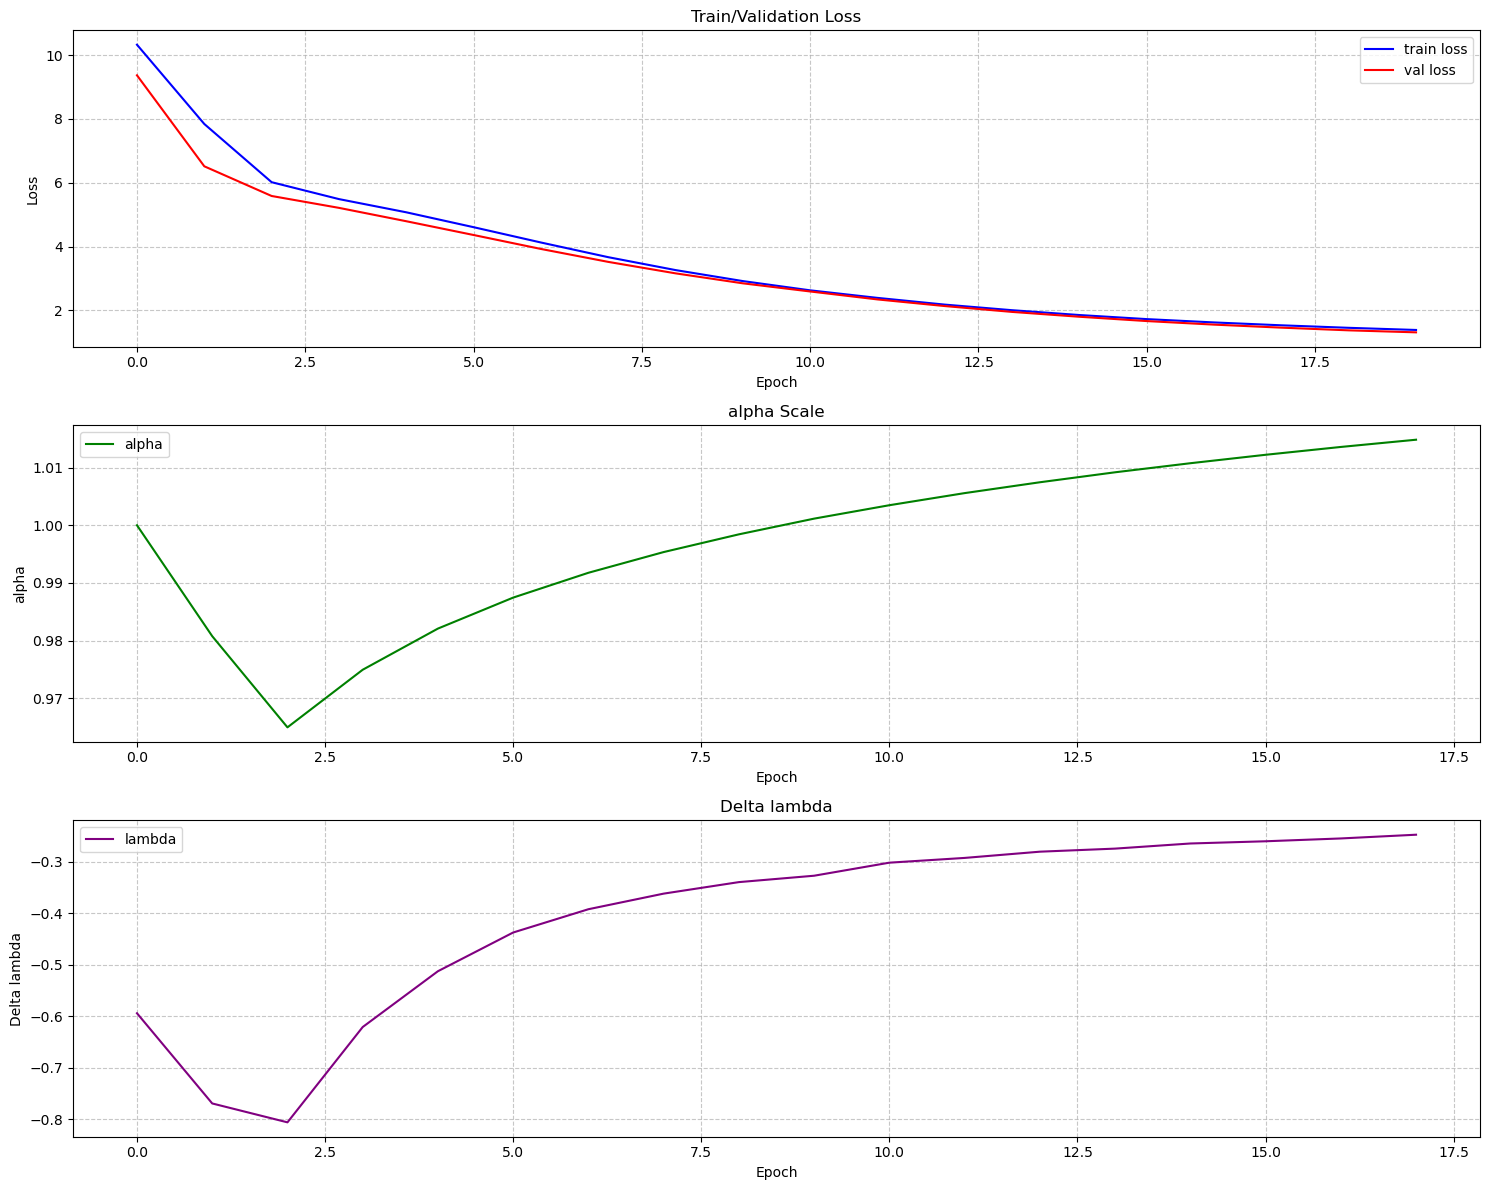

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15,12))

epochs = np.arange(len(train_loss))  
epochs_alpha = np.arange(len(alphas)) 
epochs_lambda = np.arange(len(lambdas))

ax[0].plot(train_loss, label='train loss', color='blue')
ax[0].plot(epochs, val_loss, label='val loss', color='red')
ax[0].set_title("Train/Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.7)

ax[1].plot(epochs_alpha, alphas, label='alpha', color='green')
ax[1].set_title(f"alpha Scale")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel(f"alpha")
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

ax[2].plot(epochs_lambda, lambdas, label='lambda', color='purple')
ax[2].set_title(f"Delta lambda")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel(f"Delta lambda")
ax[2].legend()
ax[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.plot()


In [ ]:
tokeniser = GPT2Tokenizer.from_pretrained('gpt2')
tokeniser.pad_token = tokeniser.eos_token

generator = GenerateGPT(model=trainGPT.model, tokenizer=tokeniser, prompt="Once upon a time, there was a dragon who loved pancakes.", max_len=100)

text = "Once upon a time, there was a dragon who loved pancakes."
tokens = tokeniser.encode(text)

output_text = generator.generate(temperature=1., top_k=50, top_p=.9)
print("Generate Text")
print(output_text)
ids = tokeniser.encode("Would you like to go outside with me")
print(tokeniser.convert_ids_to_tokens(ids))


Generate Text
Once upon a time, there was a dragon who loved pancakes. they havent just anything, you to do. you have any of the disposal of the oil. loose, or wolves. by the club high oneive always tell you be a few scratches now you be a budgeting it.shoot. be a lot of sears?i think guy where shes idea. trying to be too thing that be thirty this guy where then if you make a city is a discipline in his there are some inherent limits there are someplace where i think about credit cards
['Would', 'Ġyou', 'Ġlike', 'Ġto', 'Ġgo', 'Ġoutside', 'Ġwith', 'Ġme']


# Hyper Param Tuning #


In [17]:
def proxy_objective(trial, holdout_loader, score_loader, model):
    min_lr_rate = trial.suggest_float("min_lr", 1e-5, 3e-4)
    max_lr_rate = trial.suggest_float("max_lr", 3e-4, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    dropout = trial.suggest_float("dropout", 0.0, 0.2, step=0.05)
    seq_len = trial.suggest_categorical("block_size", [32, 64, 128])

    T_steps = trial.suggest_categorical("T_steps", [100, 500, 1000])
    t0 = trial.suggest_categorical("t0", [25, 50, 100])
    alpha_config = trial.suggest_float("alpha_scale", 0.0, 1.0)

    proxy_config = ProxyConfig(
        min_lr=min_lr_rate,
        max_lr=max_lr_rate,
        batch_size=batch_size,
        dropout=dropout,
        block_size=seq_len, 
        T_steps=T_steps,
        t0=t0,
        alpha_scale=alpha_config
    )
    
    proxy = ProxyTrain(holdout_loader, score_loader, proxy_config, model)
    proxy.train()

    scores = proxy.LearnabilityScore(type='composite')
    return scores.std().item()

def main_objective(trial, x, y, train_loader, val_loader, scheduler_configs):
    # in train configs
    min_lr = trial.suggest_float("min_lr", 1e-5, 1e-4)
    max_lr = trial.suggest_float("max_lr", 1e-4, 3e-3)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    max_len = trial.suggest_categorical("max_len", [100, 500, 1000])
    grad_accum_steps = trial.suggest_categorical("grad_accum_steps", [0, 1, 2])

    # in model block
    dropout = trial.suggest_float("dropout",0.0, 2.0)


    model_config = ModelConfig()
    model_config.dropout=dropout
    model_config.block_size = max_len

    main_configs = TrainConfig(
        min_lr=min_lr,
        max_lr=max_lr,
        batch_size=batch_size,
        max_len=max_len,
        grad_accum_steps=grad_accum_steps,
        dropout=dropout
    )
    
    scheduler = Scheduler(scheduler_configs)
    main = GPTTrainer(
        x, y, 
        train_loader,
        val_loader, 
        main_configs,
        model_config,
        scheduler
    )

    _, val_loss, _, _ = main.train()
    return np.mean(val_loss)






In [ ]:
proxy_study = optuna.create_study(direction='minimize', study_name="proxy_hps", load_if_exists=True)
proxy_study.optimize(
    lambda trial: proxy_objective(trial, holdout_loader, score_loader, GPT2Model), 
    n_trials=10, 
    )

print(f"Best Proxy Model Params: {proxy_study.best_trial}")
# optuna.visualization.plot_optimization_history(proxy_study)

[I 2025-05-07 17:04:59,971] A new study created in memory with name: proxy_hps
Proxy training:  28%|██▊       | 28/100 [00:04<00:05, 12.74it/s]

Saved proxy early checkpoint at step 25


Proxy training: 100%|██████████| 100/100 [00:09<00:00, 10.52it/s]


Saved proxy final checkpoint at step 100


100%|██████████| 8437/8437 [13:32<00:00, 10.38it/s]
[I 2025-05-07 17:18:50,516] Trial 0 finished with value: 0.06116395816206932 and parameters: {'min_lr': 0.00012097146095453125, 'max_lr': 0.0006107743023506863, 'batch_size': 64, 'dropout': 0.2, 'block_size': 128, 'T_steps': 100, 't0': 25, 'alpha_scale': 0.5281597113595726}. Best is trial 0 with value: 0.06116395816206932.
Proxy training:  53%|█████▎    | 53/100 [00:04<00:03, 12.75it/s]

...


100%|██████████| 8437/8437 [13:19<00:00, 10.56it/s]
[I 2025-05-07 19:12:37,624] Trial 8 finished with value: 0.029350005090236664 and parameters: {'min_lr': 5.7103559224660827e-05, 'max_lr': 0.0007404407620379526, 'batch_size': 64, 'dropout': 0.0, 'block_size': 64, 'T_steps': 100, 't0': 100, 'alpha_scale': 0.6804770487303347}. Best is trial 2 with value: 0.0043871402740478516.
Proxy training:  11%|█         | 53/500 [00:04<00:36, 12.34it/s]

Saved proxy early checkpoint at step 50


Proxy training: 100%|██████████| 500/500 [00:36<00:00, 13.56it/s]


Saved proxy final checkpoint at step 500


 73%|███████▎  | 6137/8437 [09:43<03:35, 10.68it/s]

In [ ]:
class SchedulerConfigs:
    data=train_dataset,
    scores=proxy_trainer.LearnabilityScore(alpha=proxy_configs.alpha_scale, type='composite')
    configs=proxy_configs,
    schedule_type='sigmoid',
    init_beta=0.3, # play with this hp and alpha
    shuffle=True

scheduler_configs = SchedulerConfigs()

main_study = optuna.create_study(direction='minimize', study_name="proxy_hps", load_if_exists=True)
main_study.optimize(
    lambda trial: main_objective(trial, X_train_tensor, y_train_tensor, train_loader, val_loader, scheduler_configs),
    n_trials=3,
    n_jobs=-1
)

print(f"Best Model Params: {main_study.best_trial}")
optuna.visualization.plot_optimization_history(main_study)

[I 2025-05-07 14:39:55,096] A new study created in memory with name: proxy_hps


KeyboardInterrupt: 

In [ ]:
# Save final model checkpoint
torch.save(trainGPT.model.state_dict(), "final_gpt_model.pt")

# Rebuild model with the same config
model = GPT2Model(model_config)  
model.load_state_dict(torch.load("final_gpt_model.pt"))
model.to(torch.device)  # don't forget to move to device!
model.eval()      # if using for inference
